In [53]:
import numpy as np
import matplotlib.pyplot as plt
import math

np.random.seed(847063)

# Exercício

1. Gere uma amostra de tamanho $M$ de uma exponencial através do método de inversão visto em sala. Compare com uma exponencial gerada pelo numpy via histogramas. Comparem também com a densidade real da exponencial $f(x) = \lambda e^{-\lambda x}$ (isto é, seu histograma normalizado tem que ficar igual essa curva).


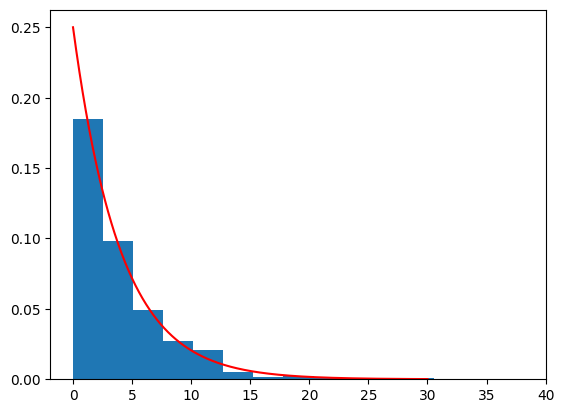

In [54]:
N = 1000
lam = 0.25
amostra = []

for i in range(N):
  x = (-1/lam) * np.log(np.random.uniform())
  amostra.append(x)

x = np.linspace(0, 30, 1000)
y = lam * np.exp(-lam * x)

plt.hist(amostra, density=True, bins=15)
plt.plot(x, y, color="red")
plt.show()

2. Agora considere $T_n = X_n / n$ onde $X_n$ é uma Geométrica com parâmetro $\lambda/n$. Mostre que quando $n$ é grande, isso se aproxima de uma exponencial.


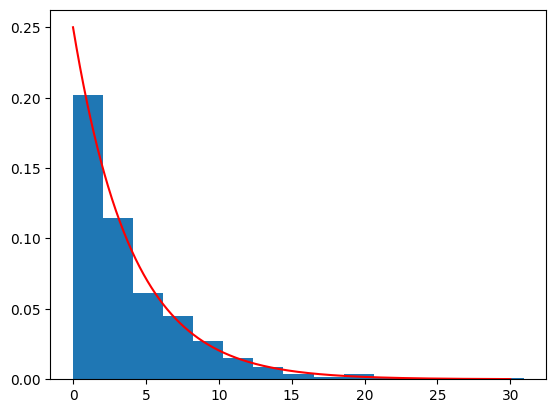

In [55]:
def geom(p):
  j = np.ceil(np.log(1 - np.random.uniform())/np.log(1-p))
  return j

N = 1000
lam = 0.25
amostra = []
n = 1000

for i in range(N):
  x = geom(lam/n)
  amostra.append(x/n)

x = np.linspace(0, 30, 1000)
y = lam * np.exp(-lam * x)


plt.hist(amostra, density=True, bins=15)
plt.plot(x, y, color="red")
plt.show()

3. Considere agora $X_1, X_2, \ldots$ variáveis aleatórias i.i.d. com distribuição Exponencial de parâmetro $\lambda$. Vá somando essas variáveis até que a soma ultrapasse $1$ e conte quantas delas foram somadas antes de ultrapassar $1$. Repita esse procedimento $M$ vezes e mostre empiricamente que essa quantidade segue aproximadamente uma Poisson de parâmetro $\lambda$. Compare o histograma obtido com uma Poisson gerada pelo numpy e com a função de probabilidade real da Poisson.

In [56]:
def poisson_exponencial(lam, M):
  amostra = []
  for i in range(M):
    x = 0
    continuar = True
    sum = 0
    while continuar:
      y = (-1/lam) * np.log(np.random.uniform())
      if(sum + y > 1):
        continuar = False
      sum += y
      x += 1
    amostra.append(x)
  return amostra

dados = poisson_exponencial(5, 10_000)

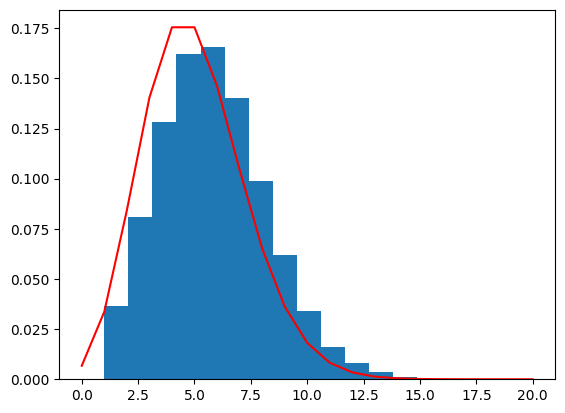

In [57]:
# Poisson Gerada por soma de exponenciais
valor = []
for x in range(21):
  y = 5**x * np.exp(-5)/math.factorial(x)
  valor.append(y)

x = [x for x in range(21)]

plt.hist(dados, density=True, bins=15)
plt.plot(x, valor, color="red")
plt.show()

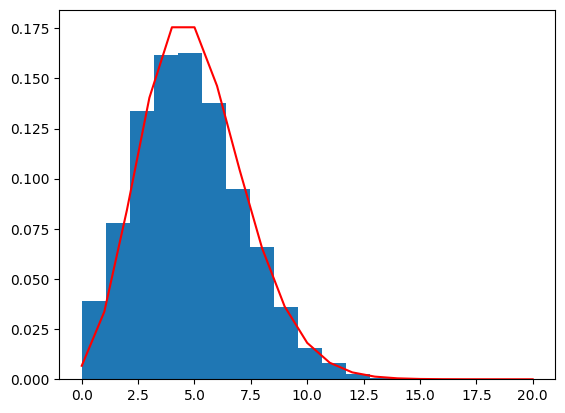

In [58]:
# Poisson Gerada pelo numpy
plt.hist(np.random.poisson(5, 10_000), density=True, bins=15)
plt.plot(x, valor, color="red")
plt.show()